In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
GENE_FEATURES = "../data/processed/final_gene_features.csv"

gene_df = pd.read_csv(GENE_FEATURES)

print("Dataset shape:", gene_df.shape)

gene_df.head()

Dataset shape: (23050, 49)


,GeneSymbol,total_variants,pathogenic_variants,benign_variants,variant_type_diversity,chromosome_diversity,unique_variant_count,description,rare_variants,gene_degree,...,node2vec_26,node2vec_27,node2vec_28,node2vec_29,node2vec_30,node2vec_31,neighbor_pathogenic_ratio,mutation_network_score,rare_network_score,label
0,-,737,34,420,9,24,728,0,317,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1
1,A-GAMMA3'E;BGLT3;HBE1;HBG1;HBG2;HS-E1;LOC10609...,1,1,0,1,1,1,0,1,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1
2,A1BG,2,0,0,1,1,2,alpha-1-B glycoprotein,2,9.0,...,-0.235506,0.363174,-0.990071,-0.345844,0.621912,0.263874,0.333333,18.0,18.0,0
3,A1CF,6,0,4,1,1,6,APOBEC1 complementation factor,2,10.0,...,-0.597971,-0.691481,-0.906847,0.525341,0.050259,0.685864,0.200000,60.0,20.0,0
4,A2M,40,0,18,2,1,40,alpha-2-macroglobulin,22,63.0,...,-0.284316,-0.017118,-0.653727,-0.331349,-0.214422,0.328736,0.666667,2520.0,1386.0,0


In [3]:
gene_df["label"] = (gene_df["pathogenic_variants"] > 0).astype(int)

In [4]:
label_counts = gene_df["label"].value_counts()

print(label_counts)

label
0    14914
1     8136
Name: count, dtype: int64


In [5]:
total = len(gene_df)

for label,count in label_counts.items():
    print(f"Class {label}: {count} ({count/total*100:.2f}%)")

Class 0: 14914 (64.70%)
Class 1: 8136 (35.30%)


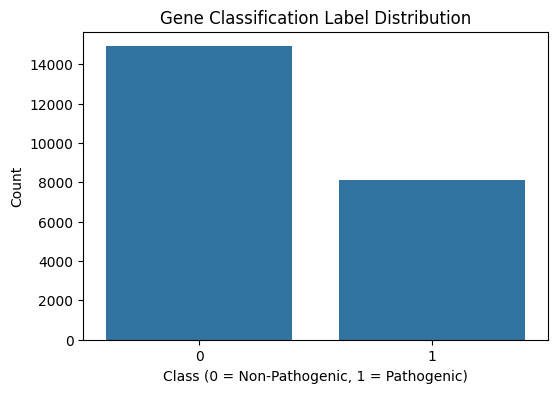

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x=gene_df["label"])

plt.title("Gene Classification Label Distribution")
plt.xlabel("Class (0 = Non-Pathogenic, 1 = Pathogenic)")
plt.ylabel("Count")

plt.show()

In [7]:
majority = label_counts.max()
minority = label_counts.min()

imbalance_ratio = majority / minority

print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 1.8330875122910522


Interpretation:

| Ratio   | Meaning            |
| ------- | ------------------ |
| < 1.5   | Balanced           |
| 1.5 – 3 | Mild imbalance     |
| 3 – 10  | Moderate imbalance |
| > 10    | Severe imbalance   |


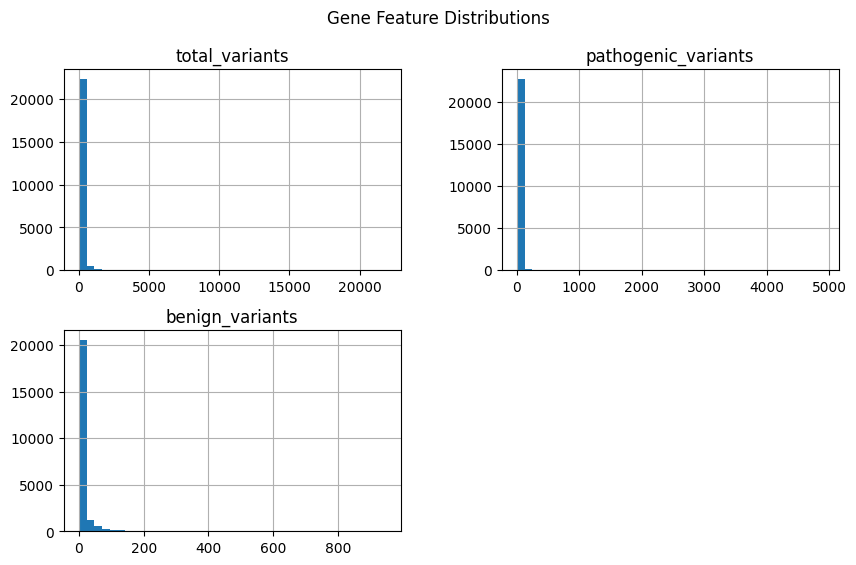

In [8]:
features = [
    "total_variants",
    "pathogenic_variants",
    "benign_variants"
]

gene_df[features].hist(
    bins=40,
    figsize=(10,6)
)

plt.suptitle("Gene Feature Distributions")

plt.show()

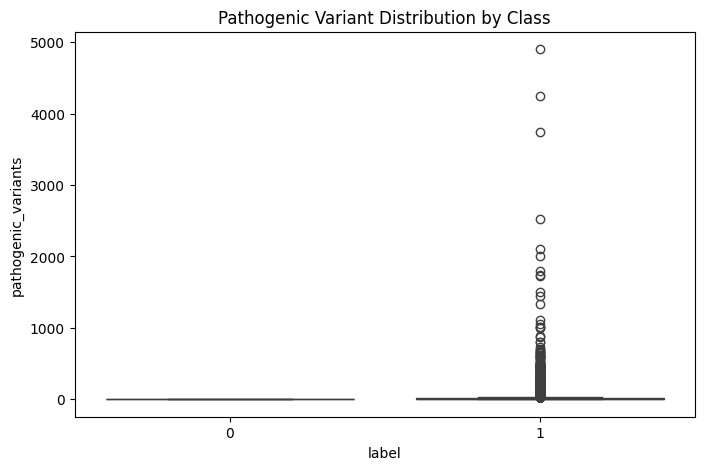

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="pathogenic_variants",
    data=gene_df
)

plt.title("Pathogenic Variant Distribution by Class")

plt.show()

In [15]:
PATIENT_DATA = "../data/processed/patient_gene_mutation_counts.csv"

patient_df = pd.read_csv(PATIENT_DATA)

patient_df.head()

,patient,chrom,pos,mutation_count
0,HG01140,1,809284,1
1,HG02549,1,925980,1
2,NA19037,1,925980,1
3,NA19346,1,925980,1
4,NA19430,1,925980,1


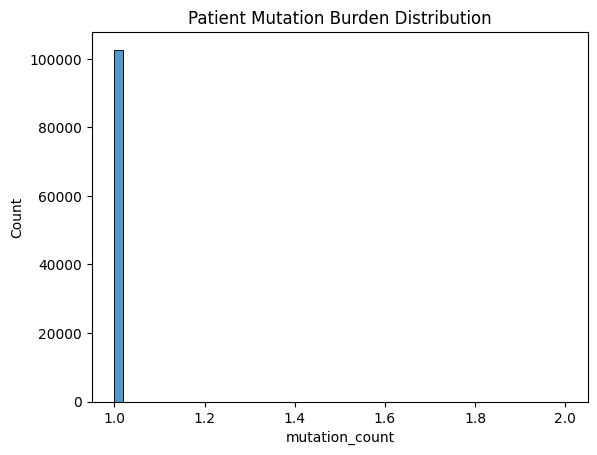

In [17]:
sns.histplot(
    patient_df["mutation_count"],
    bins=50
)

plt.title("Patient Mutation Burden Distribution")

plt.show()

In [14]:
print("Total genes:", len(gene_df))
print("Pathogenic genes:", sum(gene_df["label"]==1))
print("Non-pathogenic genes:", sum(gene_df["label"]==0))
print("Imbalance ratio:", imbalance_ratio)

Total genes: 23050
Pathogenic genes: 8136
Non-pathogenic genes: 14914
Imbalance ratio: 1.8330875122910522


In [1]:
import pandas as pd

DATA_PATH = "../data/processed/final_gene_features.csv"

df = pd.read_csv(DATA_PATH)

# Check column names first
print(df.columns)

# Replace 'label' if your column name is different
class_counts = df['label'].value_counts()

print("Class Distribution (Counts):")
print(class_counts)

Index(['GeneSymbol', 'total_variants', 'pathogenic_variants',
       'benign_variants', 'variant_type_diversity', 'chromosome_diversity',
       'unique_variant_count', 'description', 'rare_variants', 'gene_degree',
       'clustering_coefficient', 'pagerank', 'betweenness_centrality',
       'node2vec_0', 'node2vec_1', 'node2vec_2', 'node2vec_3', 'node2vec_4',
       'node2vec_5', 'node2vec_6', 'node2vec_7', 'node2vec_8', 'node2vec_9',
       'node2vec_10', 'node2vec_11', 'node2vec_12', 'node2vec_13',
       'node2vec_14', 'node2vec_15', 'node2vec_16', 'node2vec_17',
       'node2vec_18', 'node2vec_19', 'node2vec_20', 'node2vec_21',
       'node2vec_22', 'node2vec_23', 'node2vec_24', 'node2vec_25',
       'node2vec_26', 'node2vec_27', 'node2vec_28', 'node2vec_29',
       'node2vec_30', 'node2vec_31', 'neighbor_pathogenic_ratio',
       'mutation_network_score', 'rare_network_score', 'label'],
      dtype='object')
Class Distribution (Counts):
label
0    14914
1     8136
Name: count, d

In [2]:
class_percent = df['label'].value_counts(normalize=True) * 100

print("\nClass Distribution (%):")
print(class_percent)


Class Distribution (%):
label
0    64.70282
1    35.29718
Name: proportion, dtype: float64


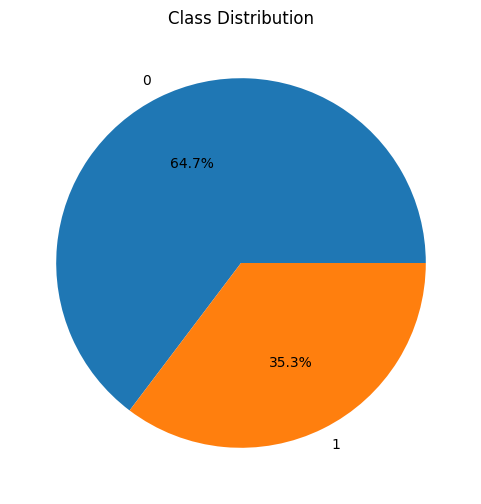

In [3]:
import matplotlib.pyplot as plt

class_counts.plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Class Distribution")
plt.ylabel('')
plt.show()

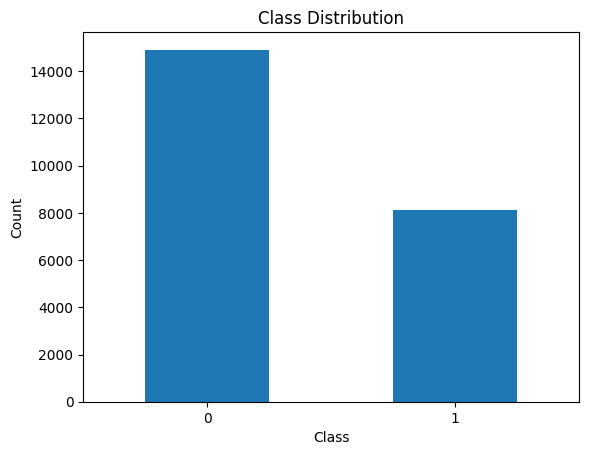

In [4]:
class_counts.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [5]:
print(df.columns.tolist())

['GeneSymbol', 'total_variants', 'pathogenic_variants', 'benign_variants', 'variant_type_diversity', 'chromosome_diversity', 'unique_variant_count', 'description', 'rare_variants', 'gene_degree', 'clustering_coefficient', 'pagerank', 'betweenness_centrality', 'node2vec_0', 'node2vec_1', 'node2vec_2', 'node2vec_3', 'node2vec_4', 'node2vec_5', 'node2vec_6', 'node2vec_7', 'node2vec_8', 'node2vec_9', 'node2vec_10', 'node2vec_11', 'node2vec_12', 'node2vec_13', 'node2vec_14', 'node2vec_15', 'node2vec_16', 'node2vec_17', 'node2vec_18', 'node2vec_19', 'node2vec_20', 'node2vec_21', 'node2vec_22', 'node2vec_23', 'node2vec_24', 'node2vec_25', 'node2vec_26', 'node2vec_27', 'node2vec_28', 'node2vec_29', 'node2vec_30', 'node2vec_31', 'neighbor_pathogenic_ratio', 'mutation_network_score', 'rare_network_score', 'label']


In [9]:
import pandas as pd

EDGE_PATH = "../data/processed/final_edge_list.csv"

# Load file
edges = pd.read_csv(EDGE_PATH)

# Check columns
print("Columns:", edges.columns.tolist())

# Automatically pick first two columns as nodes
col1, col2 = edges.columns[:2]

print(f"Using columns: {col1}, {col2}")

# Total edges
print("Total edges:", len(edges))

# Unique nodes
unique_nodes = len(set(edges[col1]).union(set(edges[col2])))
print("Unique nodes:", unique_nodes)

Columns: ['gene1', 'gene2']
Using columns: gene1, gene2
Total edges: 472000
Unique nodes: 16185


In [10]:
edges = edges.rename(columns={
    edges.columns[0]: 'source',
    edges.columns[1]: 'target'
})

# Now standard usage
print("Unique nodes:", len(set(edges['source']).union(set(edges['target']))))

Unique nodes: 16185


In [11]:
print("\nGraph Summary:")
print("Edges:", len(edges))
print("Nodes:", unique_nodes)
print("Average Degree:", (2 * len(edges)) / unique_nodes)


Graph Summary:
Edges: 472000
Nodes: 16185
Average Degree: 58.325610132839046
